In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import warnings
warnings.filterwarnings('ignore')

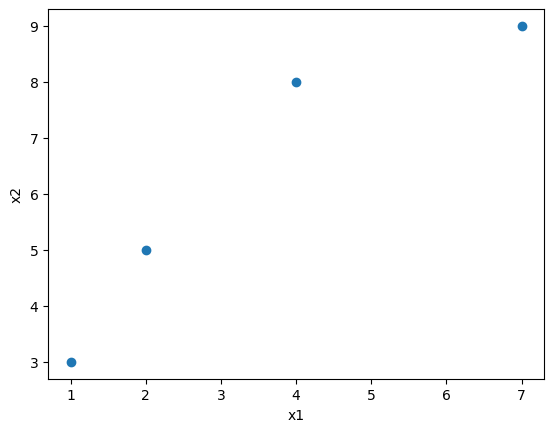

In [2]:
x1 = [1,2,4,7]
x2 = [3,5,8,9]
plt.xlabel('x1')
plt.ylabel('x2')
plt.scatter(x1,x2)
plt.show()

In [3]:
df = pd.DataFrame(list(zip(x1,x2)),columns=['x1','x2'])
df

,x1,x2
0,1,3
1,2,5
2,4,8
3,7,9


In [4]:
np.random.seed(42)
n = len(df)
k = 2
d = 2
m = 2
MAX_ITERS = 12

In [7]:
def initializeMembeshipWeights():
    weight = np.random.dirichlet(np.ones(k),size=n)
    weight_arr = np.array(weight)
    return weight_arr

def computerCentroids(weight_arr):
    c = []
    for i in range(k):
        weight_sum = np.power(weight_arr[:,i],m).sum()
        cj = []
        for x in range(d):
            num = (df.iloc[:,x].values * np.power(weight_arr[:,i],m)).sum()
            c_val = num/weight_sum
            cj.append(c_val)
        c.append(cj)
    return c

def updateWeight(weight_arr,c):
    denon = np.zeros(n)
    for i in range(k):
        dist = (df.iloc[:,:].values - c[i])**2
        dist = np.sum(dist,axis = 1)
        dist = np.square(dist)
        denon = denon + np.power(1/dist,2/(m-1))

    for i in range(k):
        dist = (df.iloc[:,:].values - c[i])**2
        dist = np.sum(dist,axis = 1)
        dist = np.square(dist)
        weight_arr[:,i] = np.divide(np.power(1/dist,2/(m-1)),denon)
    
    return weight_arr

def plotData(z,c):
    plt.subplot(4,3,z+1)
    plt.scatter(list(df.iloc[:,0]),list(df.iloc[:,1]),s=200,marker='o')
    for center in c:
        plt.scatter(center[0],center[1],s=300,marker='o',color='r')
        plt.axis('equal')
        plt.xlabel('x',fontsize=20)
        plt.ylabel('y',fontsize=20)

def fuzzyMeanAlgorithm():
    weight_arr = initializeMembeshipWeights()
    plt.figure(figsize=(50,50))
    for z in range(MAX_ITERS):
        c = computerCentroids(weight_arr)
        weight_arr = updateWeight(weight_arr,c)
        plotData(z,c)
    plt.show()
    return (weight_arr,c)

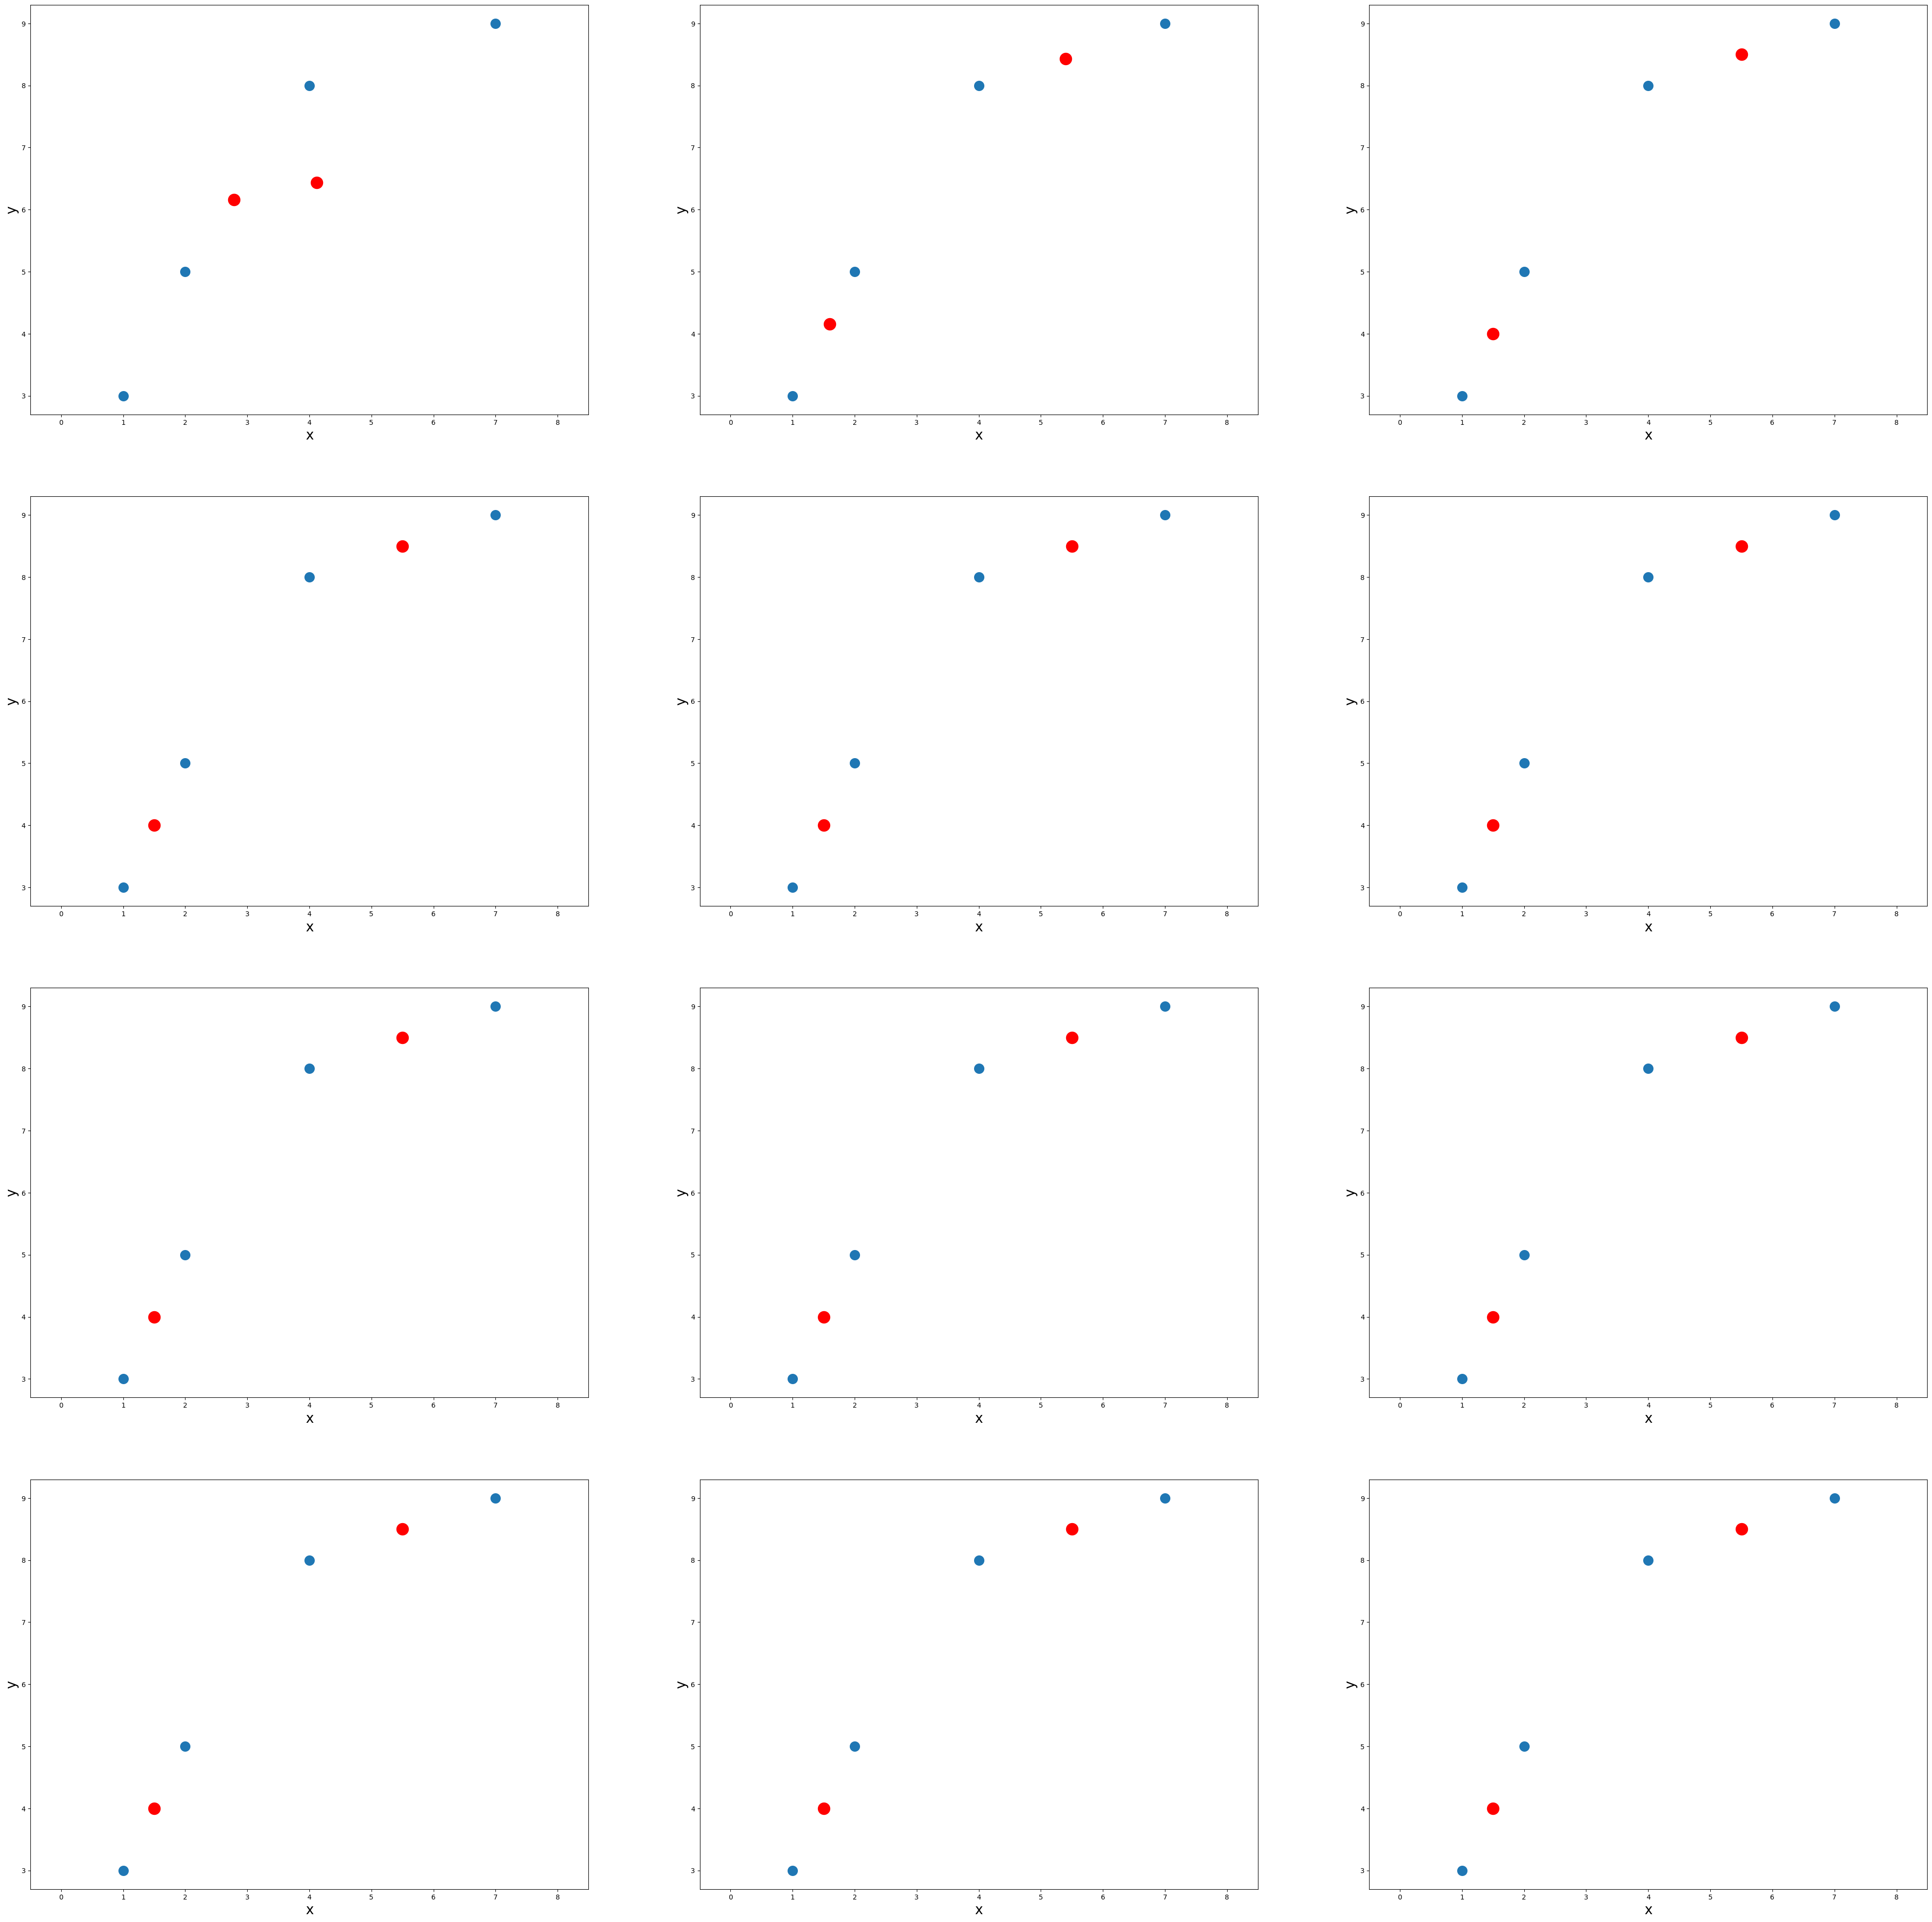

(array([[9.99999625e-01, 3.75275989e-07],
        [9.99993226e-01, 6.77392806e-06],
        [1.59553110e-04, 9.99840447e-01],
        [4.18683756e-06, 9.99995813e-01]]),
 [[1.4999968325324962, 3.9999936522837145],
  [5.500233068407617, 8.500077689415381]])

In [8]:
fuzzyMeanAlgorithm()

In [9]:
!pip install fuzzy-c-means

In [10]:
from fcmeans import FCM
from sklearn.datasets import load_iris

In [11]:
iris = load_iris()
x = pd.DataFrame(iris.data,columns=iris.feature_names)
y = pd.DataFrame(iris.target,columns=['Species'])

In [12]:
x.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [13]:
fcm = FCM(n_clusters=3)
fcm.fit(x.values)
fcm_centers = fcm.centers
fcm_labels = fcm.predict(x.values)
fcm_centers = pd.DataFrame(fcm_centers)
fcm_centers

,0,1,2,3
0,6.775011,3.052382,5.646782,2.053547
1,5.888933,2.761070,4.363953,1.397315
2,5.003966,3.414089,1.482816,0.253546


In [14]:
fcm_labels

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1])

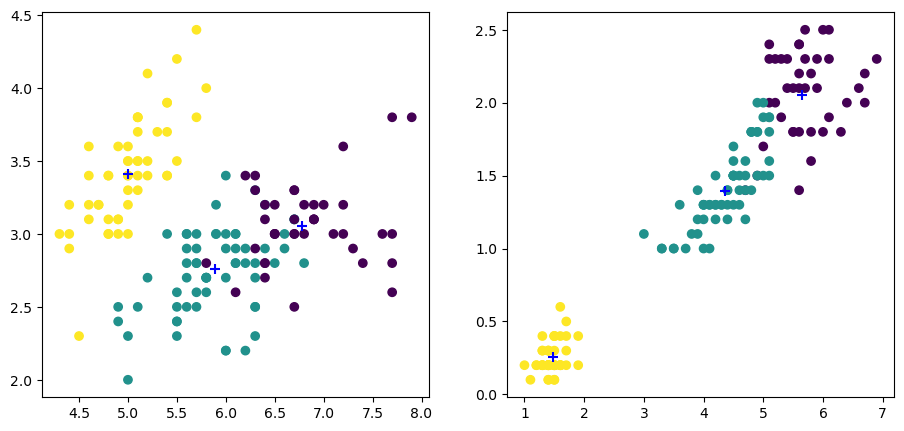

In [17]:
f,axes = plt.subplots(1,2,figsize=(11,5))
axes[0].scatter(list(x.iloc[:,0]),list(x.iloc[:,1]),c=fcm_labels)
axes[1].scatter(list(x.iloc[:,2]),list(x.iloc[:,3]),c=fcm_labels)
axes[0].scatter(fcm_centers[0],fcm_centers[1],s=50,marker='+',c='b')
axes[1].scatter(fcm_centers[2],fcm_centers[3],s=50,marker='+',c='b')

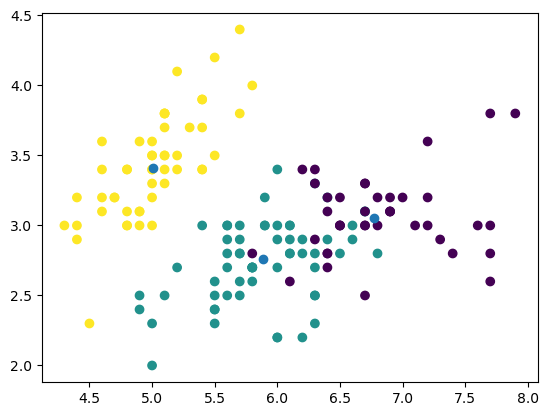

In [18]:
plt.scatter(x['sepal length (cm)'],x['sepal width (cm)'],c=fcm_labels)
plt.scatter(fcm_centers[0],fcm_centers[1])
plt.show()